# Accident Detection from CCTV Footage using CNN



In [1]:
# Import all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from glob import glob
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import VGG16
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.16.2


In [2]:
# Use the provided dataset folder directly
from pathlib import Path

DATA_DIR = Path(r'G:\ML Deployment\data')
print('Dataset directory:', DATA_DIR)
print('Exists:', DATA_DIR.exists())

if not DATA_DIR.exists():
    raise FileNotFoundError(f'The dataset folder was not found: {DATA_DIR}')

Dataset directory: G:\ML Deployment\data
Exists: True


In [3]:
# Check the folder structure from the provided dataset path
for root, dirs, files_list in os.walk(DATA_DIR):
    level = root.replace(str(DATA_DIR), '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        for f in files_list[:3]:
            print(f'{indent}  {f}')
        if len(files_list) > 3:
            print(f'{indent}  ... and {len(files_list)-3} more files')

data/
  test/
    Accident/
      acc1 (7).jpg
      test10_33.jpg
      test10_56.jpg
      ... and 44 more files
    Non Accident/
      5_23.jpg
      Pictures - Shortcut.lnk
      test10_5.jpg
      ... and 51 more files
  train/
    Accident/
      acc1 (1).jpg
      acc1 (13).jpg
      acc1 (14).jpg
      ... and 366 more files
    Non Accident/
      5_10.jpg
      5_11.jpg
      5_12.jpg
      ... and 419 more files
  val/
    Accident/
      acc1 (4).jpg
      acc1 (6).jpg
      test10_22.jpg
      ... and 43 more files
    Non Accident/
      5_16.jpg
      5_22.jpg
      5_26.jpg
      ... and 49 more files


## 2. Exploratory Data Analysis

Let's look at the dataset — how many images per class, some sample images, and image dimensions.

In [4]:
# Find the actual data directory (sometimes it's nested)
import pathlib

# Let's find where the train/test/val folders are
base_dir = DATA_DIR
for root, dirs, _ in os.walk(base_dir):
    if 'train' in dirs or 'Train' in dirs:
        base_dir = root
        break

# Try to find correct folder names
train_dir = None
test_dir = None
val_dir = None

for item in os.listdir(base_dir):
    item_lower = item.lower()
    full_path = os.path.join(base_dir, item)
    if os.path.isdir(full_path):
        if 'train' in item_lower:
            train_dir = full_path
        elif 'test' in item_lower:
            test_dir = full_path
        elif 'val' in item_lower:
            val_dir = full_path

print(f'Train directory: {train_dir}')
print(f'Test directory: {test_dir}')
print(f'Validation directory: {val_dir}')

Train directory: G:\ML Deployment\data\train
Test directory: G:\ML Deployment\data\test
Validation directory: G:\ML Deployment\data\val


In [5]:
# Count images in each split and class
def count_images(directory):
    counts = {}
    if directory and os.path.exists(directory):
        for cls in os.listdir(directory):
            cls_path = os.path.join(directory, cls)
            if os.path.isdir(cls_path):
                count = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))])
                counts[cls] = count
    return counts

train_counts = count_images(train_dir)
test_counts = count_images(test_dir)
val_counts = count_images(val_dir)

print('Training set:', train_counts)
print('Test set:', test_counts)
print('Validation set:', val_counts)
print(f'\nTotal training images: {sum(train_counts.values())}')
print(f'Total test images: {sum(test_counts.values())}')
if val_counts:
    print(f'Total validation images: {sum(val_counts.values())}')

Training set: {'Accident': 369, 'Non Accident': 422}
Test set: {'Accident': 47, 'Non Accident': 53}
Validation set: {'Accident': 46, 'Non Accident': 52}

Total training images: 791
Total test images: 100
Total validation images: 98


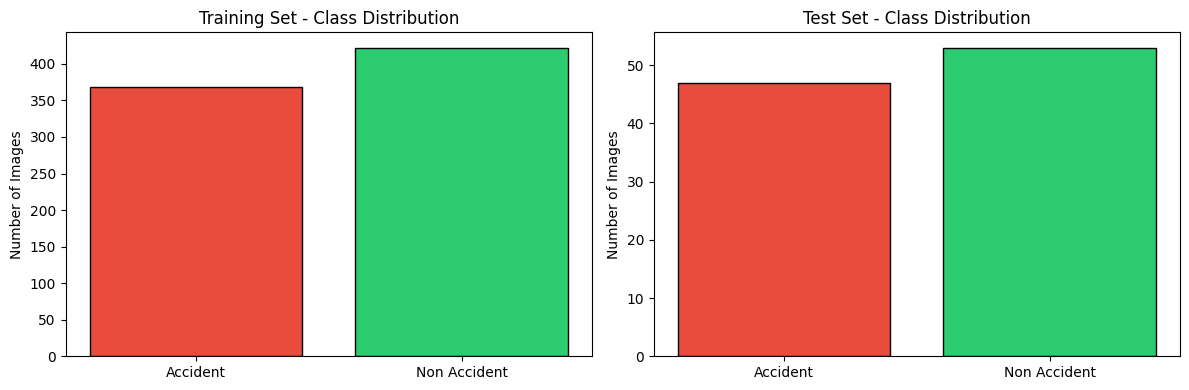

In [6]:
# Class distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(train_counts.keys(), train_counts.values(), color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Training Set - Class Distribution')
axes[0].set_ylabel('Number of Images')

if test_counts:
    axes[1].bar(test_counts.keys(), test_counts.values(), color=['#e74c3c', '#2ecc71'], edgecolor='black')
    axes[1].set_title('Test Set - Class Distribution')
    axes[1].set_ylabel('Number of Images')

plt.tight_layout()
plt.show()

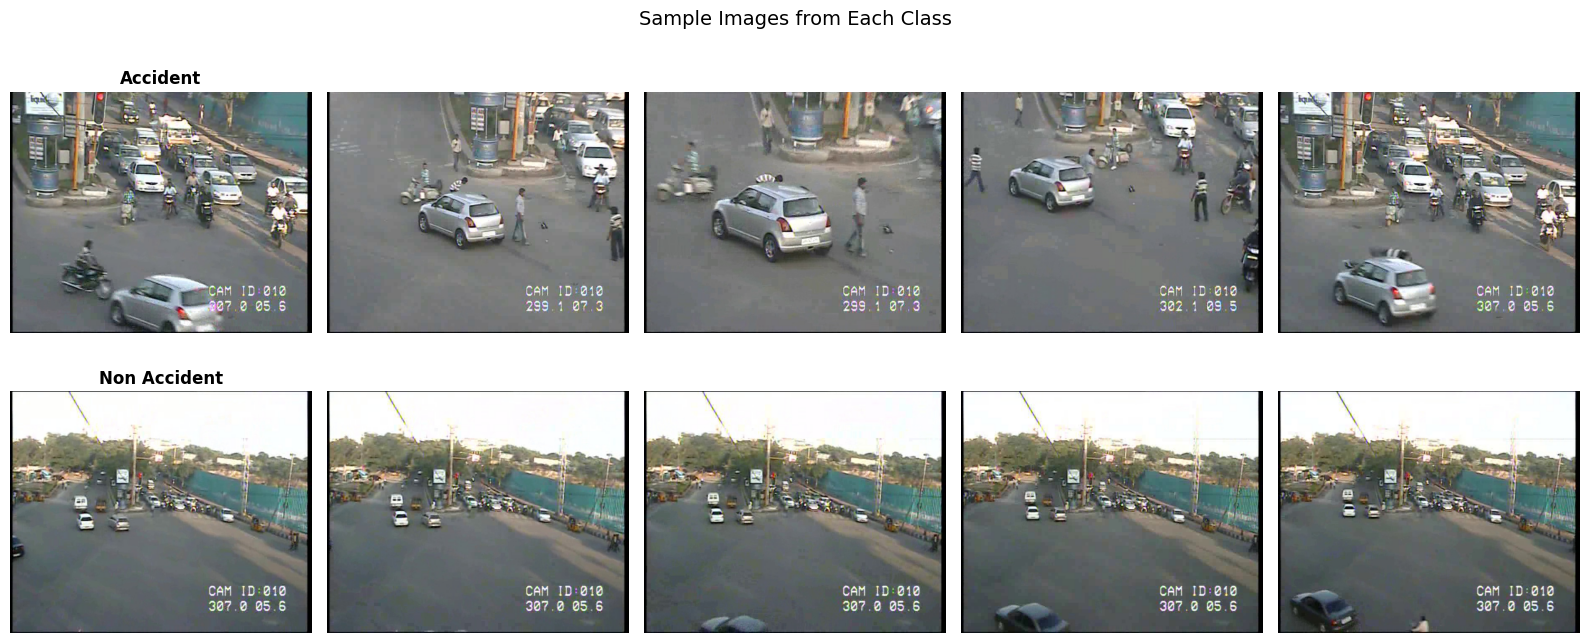

In [7]:
# Display sample images from each class
classes = list(train_counts.keys())
fig, axes = plt.subplots(2, 5, figsize=(16, 7))

for row, cls in enumerate(classes[:2]):
    cls_path = os.path.join(train_dir, cls)
    img_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))][:5]
    for col, img_file in enumerate(img_files):
        img = cv2.imread(os.path.join(cls_path, img_file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls, fontsize=12, fontweight='bold')

plt.suptitle('Sample Images from Each Class', fontsize=14)
plt.tight_layout()
plt.show()

Width  - Min: 720, Max: 1280, Mean: 1210
Height - Min: 576, Max: 720, Mean: 702


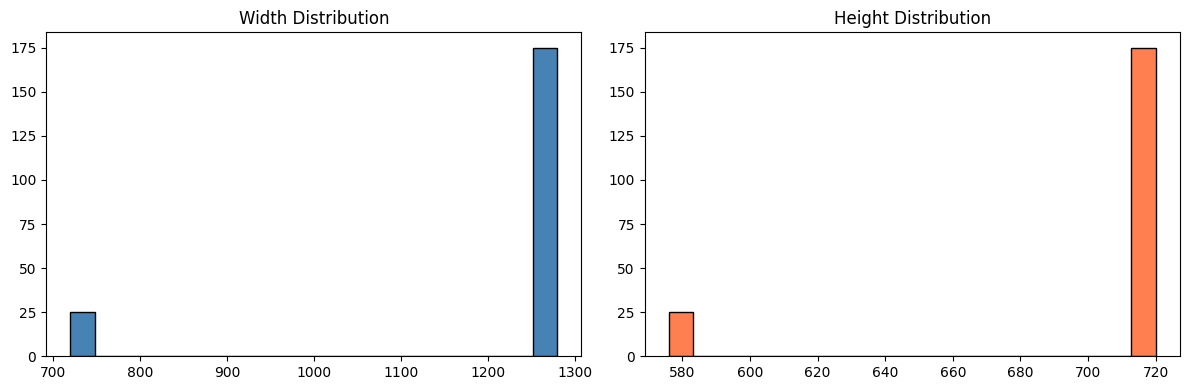

In [8]:
# Check image dimensions
widths = []
heights = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    img_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))][:100]
    for img_file in img_files:
        img = cv2.imread(os.path.join(cls_path, img_file))
        if img is not None:
            h, w = img.shape[:2]
            heights.append(h)
            widths.append(w)

print(f'Width  - Min: {min(widths)}, Max: {max(widths)}, Mean: {np.mean(widths):.0f}')
print(f'Height - Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.0f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Width Distribution')
axes[1].hist(heights, bins=20, color='coral', edgecolor='black')
axes[1].set_title('Height Distribution')
plt.tight_layout()
plt.show()


## 3. Data Preparation

We'll use `ImageDataGenerator` to load and preprocess our images. All images will be resized to 224x224.

In [9]:
# Set image parameters
IMG_SIZE = 224
BATCH_SIZE = 32

# Basic data generator (no augmentation yet)
train_datagen_basic = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen_basic.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

# Use val set if available, otherwise use test
val_directory = val_dir if val_dir and os.path.exists(val_dir) else test_dir
val_generator = test_datagen.flow_from_directory(
    val_directory,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print('\nClass indices:', train_generator.class_indices)

Found 791 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
Found 100 images belonging to 2 classes.

Class indices: {'Accident': 0, 'Non Accident': 1}


## 4. Approach 1: CNN from Scratch

Let's build a CNN from scratch and see how it does.

In [10]:
# Build CNN from scratch
cnn_scratch = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Classifier
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

cnn_scratch.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_scratch.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,012,321 (99.23 MB)

 Trainable params: 26,011,361 (99.23 MB)

 Non-trainable params: 960 (3.75 KB)

In [11]:
# Train the scratch CNN
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('cnn_scratch_best.keras', monitor='val_loss', save_best_only=True, verbose=1)

history_scratch = cnn_scratch.fit(
    train_generator,
    epochs=8  ,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6245 - loss: 0.7947
Epoch 1: val_loss improved from None to 0.69867, saving model to cnn_scratch_best.keras

Epoch 1: finished saving model to cnn_scratch_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 163s 6s/step - accuracy: 0.6245 - loss: 0.7947 - val_accuracy: 0.4694 - val_loss: 0.6987
Epoch 2/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6435 - loss: 0.6923
Epoch 2: val_loss did not improve from 0.69867
25/25 ━━━━━━━━━━━━━━━━━━━━ 128s 5s/step - accuracy: 0.6435 - loss: 0.6923 - val_accuracy: 0.5306 - val_loss: 0.7252
Epoch 3/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6802 - loss: 0.6383
Epoch 3: val_loss did not improve from 0.69867
25/25 ━━━━━━━━━━━━━━━━━━━━ 136s 5s/step - accuracy: 0.6802 - loss: 0.6383 - val_accuracy: 0.4694 - val_loss: 0.7483
Epoch 4/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7295 - loss: 0.5755
Epoch 4: val_loss did not improve from 0.69867
25/25 ━━━━━━━━━━━━━━━━━━━━ 199s 8s/st

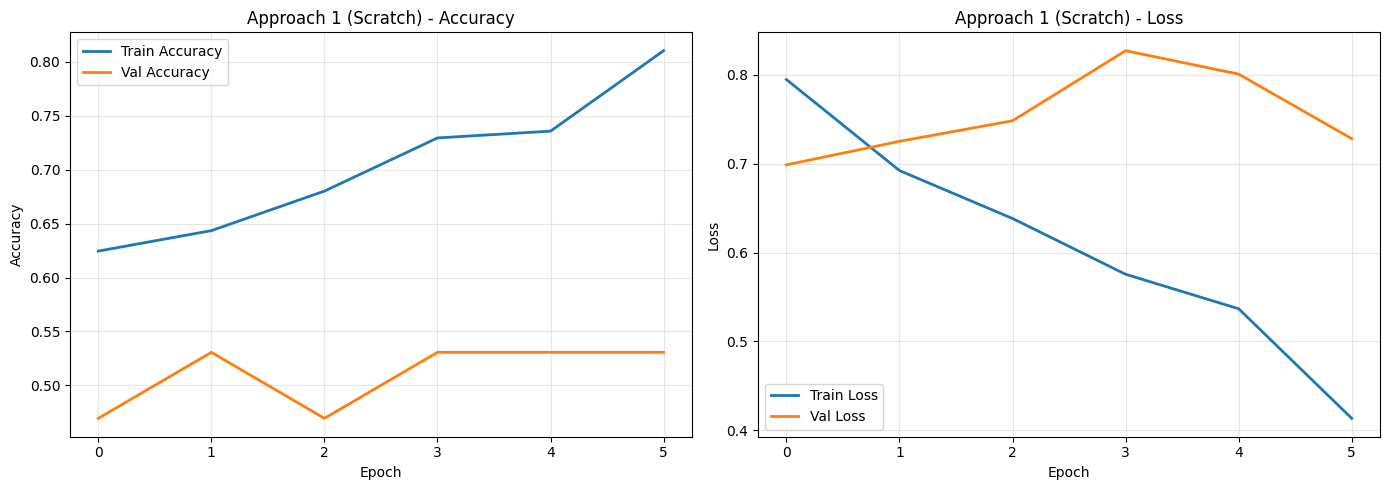

In [12]:
# Plot training curves for scratch model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_scratch.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history_scratch.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_title('Approach 1 (Scratch) - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_scratch.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history_scratch.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_title('Approach 1 (Scratch) - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Evaluate scratch model on test set
test_generator.reset()
scratch_test_loss, scratch_test_acc = cnn_scratch.evaluate(test_generator, verbose=0)
print(f'Scratch CNN - Test Accuracy: {scratch_test_acc:.4f}')
print(f'Scratch CNN - Test Loss: {scratch_test_loss:.4f}')

# Get training accuracy (last epoch)
scratch_train_acc = history_scratch.history['accuracy'][-1]
print(f'Scratch CNN - Train Accuracy: {scratch_train_acc:.4f}')

Scratch CNN - Test Accuracy: 0.4700
Scratch CNN - Test Loss: 0.6977
Scratch CNN - Train Accuracy: 0.8104


## 5. Approach 2: Transfer Learning with VGG16

Lets see if a pretrained model can do better. VGG16 has been trained on millions of images so it should know good features already.

In [14]:
# Load VGG16 pretrained model (without the top classification layers)
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze the base model layers — we don't want to retrain them
for layer in base_model.layers:
    layer.trainable = False

print(f'VGG16 loaded with {len(base_model.layers)} layers (all frozen)')

VGG16 loaded with 19 layers (all frozen)


In [15]:
# Add our own classification head on top of VGG16
model_vgg = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_vgg.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,880,065 (56.76 MB)

 Trainable params: 164,865 (644.00 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

In [16]:
# Train the VGG16 model
early_stop_vgg = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
checkpoint_vgg = ModelCheckpoint('vgg16_best.keras', monitor='val_loss', save_best_only=True, verbose=1)

# Reset generators
train_generator.reset()
val_generator.reset()

history_vgg = model_vgg.fit(
    train_generator,
    epochs=8,
    validation_data=val_generator,
    callbacks=[early_stop_vgg, checkpoint_vgg],
    verbose=1
)


Epoch 1/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5702 - loss: 0.7910
Epoch 1: val_loss improved from None to 0.68368, saving model to vgg16_best.keras

Epoch 1: finished saving model to vgg16_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 240s 9s/step - accuracy: 0.5702 - loss: 0.7910 - val_accuracy: 0.6633 - val_loss: 0.6837
Epoch 2/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.6081 - loss: 0.7075 
Epoch 2: val_loss improved from 0.68368 to 0.67689, saving model to vgg16_best.keras

Epoch 2: finished saving model to vgg16_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 299s 12s/step - accuracy: 0.6081 - loss: 0.7075 - val_accuracy: 0.6531 - val_loss: 0.6769
Epoch 3/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.6384 - loss: 0.6762
Epoch 3: val_loss improved from 0.67689 to 0.67029, saving model to vgg16_best.keras

Epoch 3: finished saving model to vgg16_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 246s 10s/step - accuracy: 0.6384 - loss: 0.6762 - val_accuracy: 0.6531 - val_loss: 0

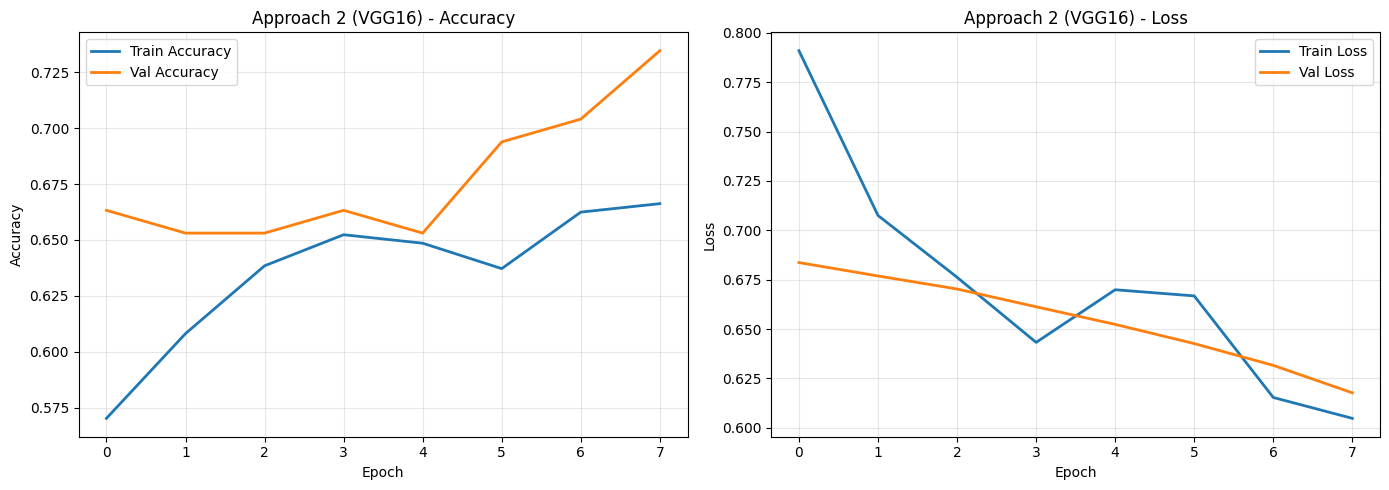

In [17]:
# Plot VGG16 training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_vgg.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history_vgg.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_title('Approach 2 (VGG16) - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_vgg.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history_vgg.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_title('Approach 2 (VGG16) - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# Evaluate VGG16 model
test_generator.reset()
vgg_test_loss, vgg_test_acc = model_vgg.evaluate(test_generator, verbose=0)
print(f'VGG16 - Test Accuracy: {vgg_test_acc:.4f}')
print(f'VGG16 - Test Loss: {vgg_test_loss:.4f}')

vgg_train_acc = history_vgg.history['accuracy'][-1]
print(f'VGG16 - Train Accuracy: {vgg_train_acc:.4f}')
# Transfer learning usually gives a nice boost!

VGG16 - Test Accuracy: 0.7000
VGG16 - Test Loss: 0.6247
VGG16 - Train Accuracy: 0.6662


## 6. Approach 3: VGG16 with Data Augmentation

Now lets add data augmentation on top of VGG16 and see if we can squeeze out even more performance. Augmentation should help reduce overfitting.

In [19]:
# Create augmented data generator
train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator_aug = train_datagen_aug.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

print('Augmented data generator created!')

Found 791 images belonging to 2 classes.
Augmented data generator created!


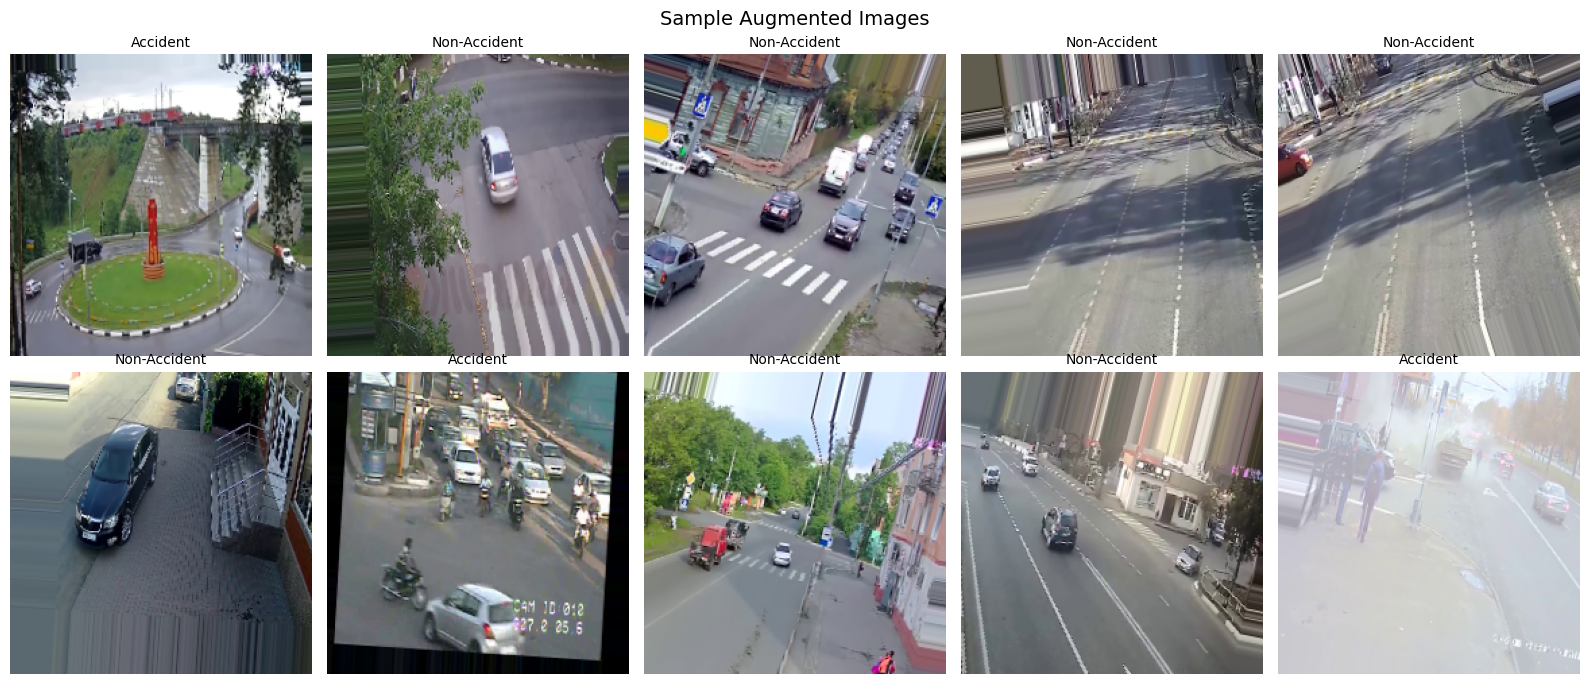

In [20]:
# Show some augmented images to see what they look like
fig, axes = plt.subplots(2, 5, figsize=(16, 7))

# Get a batch of augmented images
batch_images, batch_labels = next(train_generator_aug)

for i in range(10):
    ax = axes[i//5, i%5]
    ax.imshow(batch_images[i])
    label = 'Accident' if batch_labels[i] == 0 else 'Non-Accident'
    ax.set_title(label, fontsize=10)
    ax.axis('off')

plt.suptitle('Sample Augmented Images', fontsize=14)
plt.tight_layout()
plt.show()

In [21]:
# Build a fresh VGG16 model for augmented training
base_model_aug = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
for layer in base_model_aug.layers:
    layer.trainable = False

model_vgg_aug = Sequential([
    base_model_aug,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_vgg_aug.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print('VGG16 + Augmentation model ready!')

VGG16 + Augmentation model ready!


In [22]:
# Train with augmented data
early_stop_aug = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
checkpoint_aug = ModelCheckpoint('vgg16_aug_best.keras', monitor='val_loss', save_best_only=True, verbose=1)

val_generator.reset()

history_aug = model_vgg_aug.fit(
    train_generator_aug,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop_aug, checkpoint_aug],
    verbose=1
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.5209 - loss: 1.0130
Epoch 1: val_loss improved from None to 0.70089, saving model to vgg16_aug_best.keras

Epoch 1: finished saving model to vgg16_aug_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 217s 9s/step - accuracy: 0.5209 - loss: 1.0130 - val_accuracy: 0.5306 - val_loss: 0.7009
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5537 - loss: 0.8886
Epoch 2: val_loss improved from 0.70089 to 0.68402, saving model to vgg16_aug_best.keras

Epoch 2: finished saving model to vgg16_aug_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 227s 9s/step - accuracy: 0.5537 - loss: 0.8886 - val_accuracy: 0.5306 - val_loss: 0.6840
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.5752 - loss: 0.7904
Epoch 3: val_loss improved from 0.68402 to 0.67515, saving model to vgg16_aug_best.keras

Epoch 3: finished saving model to vgg16_aug_best.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 249s 10s/step - accuracy: 0.5752 - loss: 0.7904 - val_accura

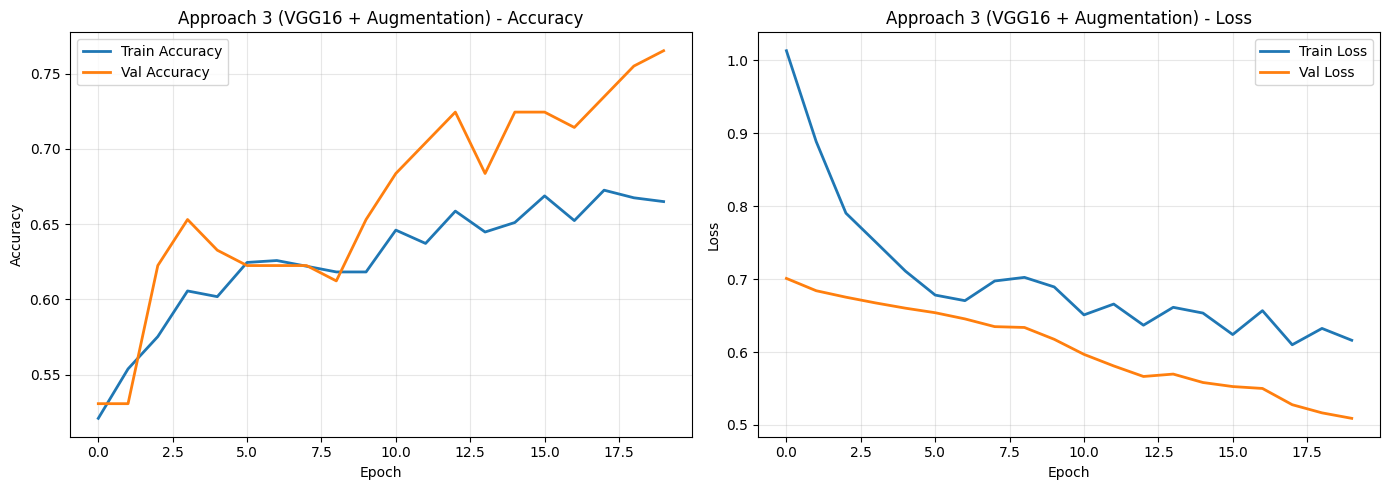

In [23]:
# Plot augmented model training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_aug.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history_aug.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_title('Approach 3 (VGG16 + Augmentation) - Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_aug.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history_aug.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_title('Approach 3 (VGG16 + Augmentation) - Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# Evaluate augmented model
test_generator.reset()
aug_test_loss, aug_test_acc = model_vgg_aug.evaluate(test_generator, verbose=0)
print(f'VGG16 + Augmentation - Test Accuracy: {aug_test_acc:.4f}')
print(f'VGG16 + Augmentation - Test Loss: {aug_test_loss:.4f}')

aug_train_acc = history_aug.history['accuracy'][-1]
print(f'VGG16 + Augmentation - Train Accuracy: {aug_train_acc:.4f}')

VGG16 + Augmentation - Test Accuracy: 0.7000
VGG16 + Augmentation - Test Loss: 0.5587
VGG16 + Augmentation - Train Accuracy: 0.6650


## 7. Model Comparison

Now let's compare all 3 approaches side by side and decide which one is the best.

In [25]:
# Create comparison dataframe
results = pd.DataFrame({
    'Approach': ['CNN from Scratch', 'VGG16 (Transfer Learning)', 'VGG16 + Data Augmentation'],
    'Train Accuracy': [scratch_train_acc, vgg_train_acc, aug_train_acc],
    'Test Accuracy': [scratch_test_acc, vgg_test_acc, aug_test_acc],
    'Overfitting Gap': [
        scratch_train_acc - scratch_test_acc,
        vgg_train_acc - vgg_test_acc,
        aug_train_acc - aug_test_acc
    ]
})

print('='*70)
print('                    MODEL COMPARISON SUMMARY')
print('='*70)
print(results.to_string(index=False))
print('='*70)

                    MODEL COMPARISON SUMMARY
                 Approach  Train Accuracy  Test Accuracy  Overfitting Gap
         CNN from Scratch        0.810367           0.47         0.340367
VGG16 (Transfer Learning)        0.666245           0.70        -0.033755
VGG16 + Data Augmentation        0.664981           0.70        -0.035019


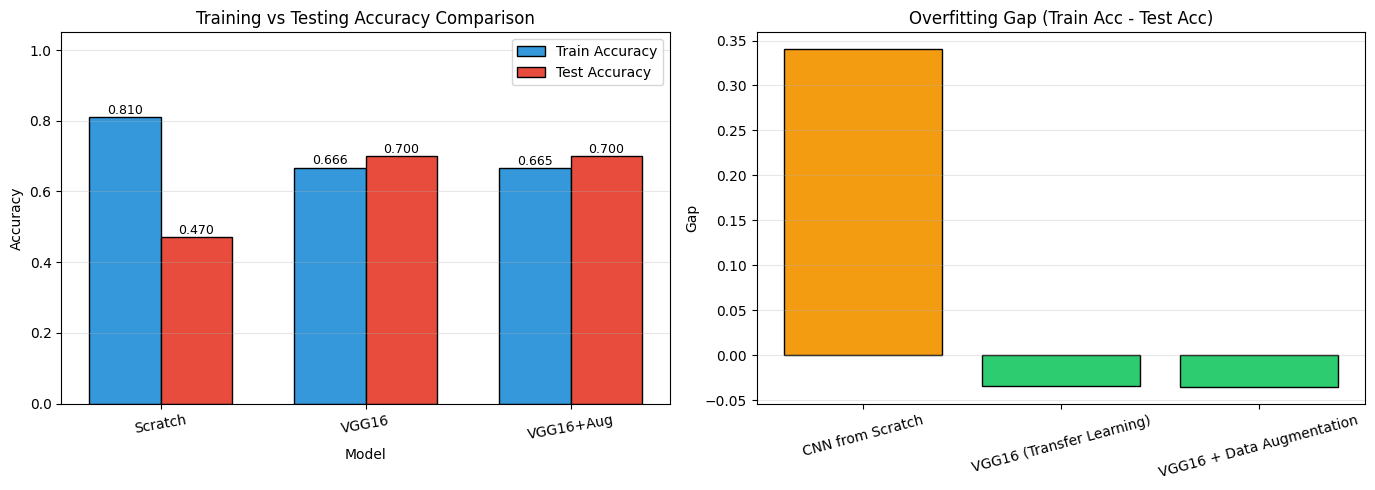

In [26]:
# Visualization - comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(results))
width = 0.35

# Train vs Test accuracy
bars1 = axes[0].bar(x - width/2, results['Train Accuracy'], width, label='Train Accuracy', color='#3498db', edgecolor='black')
bars2 = axes[0].bar(x + width/2, results['Test Accuracy'], width, label='Test Accuracy', color='#e74c3c', edgecolor='black')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Training vs Testing Accuracy Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Scratch', 'VGG16', 'VGG16+Aug'], rotation=10)
axes[0].legend()
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', fontsize=9)

# Overfitting gap
colors = ['#f39c12' if gap > 0.1 else '#2ecc71' for gap in results['Overfitting Gap']]
axes[1].bar(results['Approach'], results['Overfitting Gap'], color=colors, edgecolor='black')
axes[1].set_title('Overfitting Gap (Train Acc - Test Acc)')
axes[1].set_ylabel('Gap')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# Final recommendation
best_idx = results['Test Accuracy'].idxmax()
best_model_name = results.loc[best_idx, 'Approach']
best_test_acc = results.loc[best_idx, 'Test Accuracy']
best_train_acc = results.loc[best_idx, 'Train Accuracy']

print('\n' + '='*60)
print('           FINAL RECOMMENDATION')
print('='*60)
print(f'\nBest Model: {best_model_name}')
print(f'Training Accuracy: {best_train_acc:.4f}')
print(f'Test Accuracy: {best_test_acc:.4f}')
print(f'Overfitting Gap: {best_train_acc - best_test_acc:.4f}')
print('\n' + '='*60)

if best_idx == 0:
    print('\nThe CNN trained from scratch performed the best!')
    print('This could mean the dataset is simple enough that a custom CNN is sufficient.')
elif best_idx == 1:
    print('\nVGG16 with transfer learning gave the best results!')
    print('The pretrained features from ImageNet helped the model understand the images better.')
else:
    print('\nVGG16 with data augmentation performed the best!')
    print('Augmentation helped reduce overfitting and improved generalization.')
    print('This is the recommended model for deployment.')


           FINAL RECOMMENDATION

Best Model: VGG16 (Transfer Learning)
Training Accuracy: 0.6662
Test Accuracy: 0.7000
Overfitting Gap: -0.0338


VGG16 with transfer learning gave the best results!
The pretrained features from ImageNet helped the model understand the images better.
